## Вторая часть группового проекта

**Бизнес-задача**

Строится новое НИИ для работы над проблемами диабета, сейчас в ожидании утверждения нахожится план постройки, который нужно либо одобрить, либо отправить на доработку.

Сейчас план представляет собой два корпуса: один исследоватльский, другой - амбулаторный. ВТорое здание представляет собой симметричное строение, где осб симметрии делит участки на женские и мужские.

План этого здания отдали на утверждение отделу аналитики, это наша команда. Сейчас нам важно посмотреть на исторические данные и понять, подхожит ли такой план.

Для этого был выбран датасет [Diabetes 130-US Hospitals for Years 1999-2008](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008). Займемся его предобработкой.

В базе данных два датасета

**diabetic_data.csv** - основной датасет

**IDS_mapping.csv** - расшифровка кодов admission_type_id (Тип поступления в больницу), discharge_disposition_id (Куда выписан пациент), admission_source_id (Откуда поступил пациент)

Признаки, которые есть у датасета `diabetic_data`:

**encounter_id** - ID госпитализации

**patient_nbr** - ID пациента


***Демография***

**race** - Раса пациента   

**gender** - Пол

**age** - Возрастная группа

**weight** - Вес

**time_in_hospital** - количество дней в больнице

***Плательщик и специальность врача***

**payer_code** - код страховой компании / плательщика

**medical_specialty** - Специальность лечащего / принимающего врача

***Количество процедур, лекарств, диагнозов***

**num_lab_procedures** - Количество лабораторных процедур

**num_procedures**	Количество нелабораторных процедур

**num_medications** -	Количество назначенных препаратов

**number_outpatient** -	Количество визитов без  за предыдущий год

**number_emergency** - Количество визитов через экстренный вызов за предыдущий год

**number_inpatient**	Количество стационарных госпитализаций за предыдущий год

**number_diagnoses** - Количество диагнозов

***Диагнозы***

**diag_1** - Основной диагноз

**diag_2** - Вторичный диагноз

**diag_3** - Дополнительный диагноз

***Лабораторные показатели***

**max_glu_serum** - Уровень глюкозы в крови: Norm / >200 / >300

**A1Cresult** - Гликированный гемоглобин: Norm / >7 / >8

***Препараты***

Для каждого препарата указано, как изменилась дозировка во время госпитализации

**metformin**	- Метформин

**repaglinide**	- Репаглинид

**nateglinide**	- Натеглинид

**chlorpropamide** - Хлорпропамид

**glimepiride**	- Глимепирид

**acetohexamide**	- Ацетогексамид

**glipizide**	- Глипизид

**glyburide**	- Глибурид

**tolbutamide**	- Толбутамид

**pioglitazone**	- Пиоглитазон

**rosiglitazone**	- Росиглитазон

**acarbose**	- Акарбоза

**miglitol**	- Миглитол

**troglitazone** -	Троглитазон

**tolazamide** - Толазамид

**examide**	- Экзамид

**citoglipton**	- Цитоглиптон

**insulin**	- Инсулин

**glyburide-metformin**	- Комбинация глибурида и метформина

**glipizide-metformin**	- Комбинация глипизида и метформина

**glimepiride-pioglitazone**	- Комбинация глимепирида и пиоглитазона

**metformin-rosiglitazone**	- Комбинация метформина и росиглитазона

**metformin-pioglitazone** - Комбинация метформина и пиоглитазона

***Общие признаки по лечению диабета***

**change** - Было ли изменение диабетического лечения Ch — да, No — нет

**diabetesMed** - Назначались ли диабетические препараты Yes / No

**readmitted** - Была ли повторная госпитализация и когда

In [235]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [236]:
df = pd.read_csv('./data/diabetic_data.csv')

In [237]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [238]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

В датасете больше 100 тысяч наблюдений. Одна строка соответствует одному случаю госпитализации, а не одному уникальному пациенту

## Пропуски

In [239]:
marks = (df == '?').sum().sort_values(ascending=False)
marks[marks > 0]

weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

In [240]:
df = df.replace('?', np.nan)

In [241]:
missing_percent = df.isna().mean().sort_values(ascending=False) * 100
missing_percent.loc[missing_percent>0]

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64

Удалим колонки, в который больше 80% пропусков.

Удалим колонку `payer_code` - это не нужно для анализа.

Удалим колонку `medical_specialty` - это так же не важно для анализа пациентов.

In [242]:
drop_columns = ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty', 'payer_code']
df = df.drop(columns=drop_columns)


In [243]:
df['gender'].value_counts()

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

удалим `Unknown/Invalid` пол

In [244]:
df = df[df.gender != "Unknown/Invalid"]

## Посмотрим на дубликаты

In [245]:
df.duplicated().sum()

np.int64(0)

а сколько у нас уникальных пациентов?

In [246]:
ratio = df['patient_nbr'].nunique() / len(df)
f"{round(ratio, 3)} is the ratio of unique users"

'0.703 is the ratio of unique users'

То есть большая часть наших наблюдений **зависима**

**Cлучаи смерти и хосписа**

Если пациент умер или был переведён в хоспис, то отсутствие повторной госпитализации нельзя сравнивать с обычными пациентами

Такие случаи закодированы в discharge_disposition_id

In [247]:
death_or_hospice = [11, 13, 14, 19, 20, 21]

df["is_dead"] = df['discharge_disposition_id'].isin(death_or_hospice)

In [248]:
df.is_dead.head()

0    False
1    False
2    False
3    False
4    False
Name: is_dead, dtype: bool

**Удаление лекарств, которые в 99% всегда равны No**

In [249]:
medicine_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

medicine_cols = [col for col in medicine_cols if col in df.columns]

In [250]:
no_table = pd.DataFrame({'no_percent': (df[medicine_cols] == 'No').mean() * 100, 'unique_values': df[medicine_cols].nunique()}).sort_values('no_percent', ascending=False)

no_table

,no_percent,unique_values
citoglipton,100.000000,1
examide,100.000000,1
metformin-pioglitazone,99.999017,2
glimepiride-pioglitazone,99.999017,2
acetohexamide,99.999017,2
metformin-rosiglitazone,99.998035,2
troglitazone,99.997052,2
glipizide-metformin,99.987225,2
tolbutamide,99.977398,2
miglitol,99.962658,4


In [251]:
no_limit = 99

low_information_medicine_cols = no_table[no_table['no_percent'] > no_limit].index.tolist()
low_information_medicine_cols

['citoglipton',
 'examide',
 'metformin-pioglitazone',
 'glimepiride-pioglitazone',
 'acetohexamide',
 'metformin-rosiglitazone',
 'troglitazone',
 'glipizide-metformin',
 'tolbutamide',
 'miglitol',
 'tolazamide',
 'chlorpropamide',
 'acarbose',
 'nateglinide',
 'glyburide-metformin']

In [252]:
df = df.drop(columns=low_information_medicine_cols)

Рассмотрим **раннюю повторную госпитализацию**

readmitted_30 = 1 - пациент вернулся в больницу в течение 30 дней
readmitted_30 = 0 - пациент не вернулся в течение 30 дней

In [253]:
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)
df['readmitted_any'] = (df['readmitted'] != 'NO').astype(int)

**Анализ возраста и пола**

Так как в исходном датасете одна строка соответствует госпитализации, один и тот же пациент может встречаться несколько раз.

Поэтому для анализа возраста и пола я создам отдельную таблицу на уровне уникальных пациентов. В ней каждый patient_nbr будет встречаться только один раз.

Для пола и возраста беру первое встреченное значение пациента, а для readmitted_30 использую максимум:
если у пациента хотя бы однажды была ранняя повторная госпитализация, значение будет 1.

In [254]:
patient_demo = (df.groupby('patient_nbr').agg(age=('age', 'first'), gender=('gender', 'first'), readmitted_30=('readmitted_30', 'max')).reset_index())
patient_demo.head()

,patient_nbr,age,gender,readmitted_30
0,135,[50-60),Female,1
1,378,[50-60),Female,0
2,729,[80-90),Female,0
3,774,[80-90),Female,0
4,927,[30-40),Female,0


In [255]:
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
patient_demo['age'] = pd.Categorical(patient_demo['age'], categories=age_order, ordered=True)

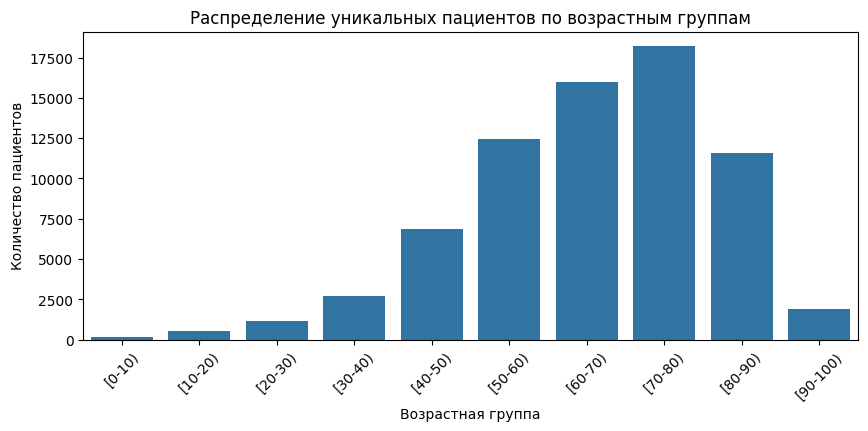

In [256]:
plt.figure(figsize=(10, 4))

sns.countplot(data=patient_demo, x='age', order=age_order)

plt.title('Распределение уникальных пациентов по возрастным группам')
plt.xlabel('Возрастная группа')
plt.ylabel('Количество пациентов')
plt.xticks(rotation=45)

plt.show()

In [257]:
age_again = patient_demo.groupby('age')['readmitted_30'].mean() * 100

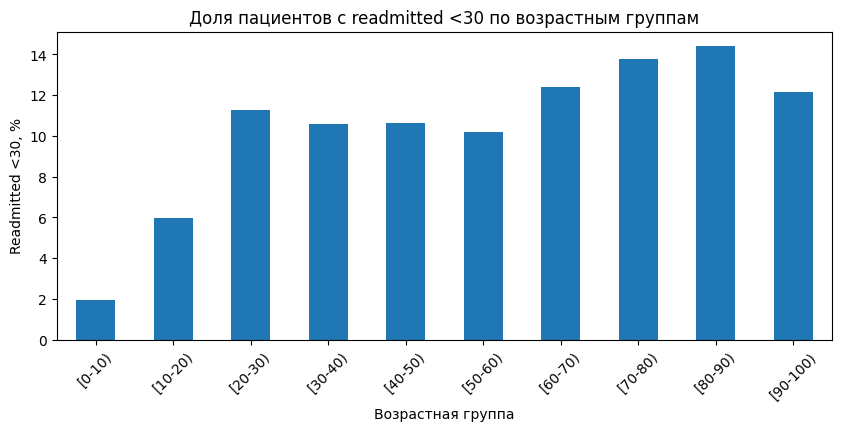

In [258]:
plt.figure(figsize=(10, 4))

age_again.plot(kind='bar')

plt.title('Доля пациентов с readmitted <30 по возрастным группам')
plt.xlabel('Возрастная группа')
plt.ylabel('Readmitted <30, %')
plt.xticks(rotation=45)

plt.show()

На первом графике показано распределение уникальных пациентов по возрастным группам. Видно, что в датасете преобладают пациенты старших возрастных групп.

На втором графике показана доля уникальных пациентов, у которых хотя бы раз была ранняя повторная госпитализация

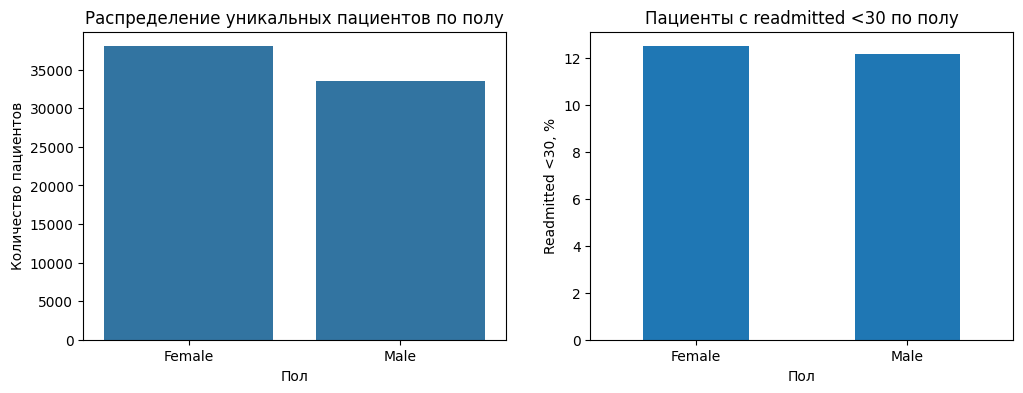

**Рассмотрим основные числовые признаки**

Разделили числовые признаки на две группы.

Первая группа описывает **текущую госпитализацию**:
- time_in_hospital - сколько дней пациент провёл в больнице;
- num_lab_procedures - количество лабораторных процедур;
- num_procedures - количество других процедур;
- num_medications - количество назначенных лекарств;
- number_diagnoses - количество диагнозов.

Вторая группа описывает **предыдущую медицинскую активность пациента**:
- number_outpatient - количество outpatient-визитов за предыдущий год
- number_emergency - количество emergency-визитов за предыдущий год
- number_inpatient - количество inpatient-госпитализаций за предыдущий год.

Такой подход логичен, потому что повторная госпитализация может быть связана как со сложностью текущего случая, так и с тем, насколько часто пациент уже обращался за медицинской помощью раньше


Распределения числовых признаков **текущей госпитализации**

In [260]:
num_current = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses']
num_history = ['number_outpatient', 'number_emergency', 'number_inpatient']

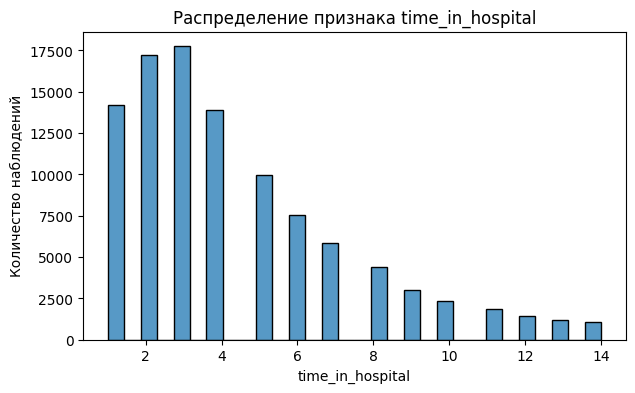

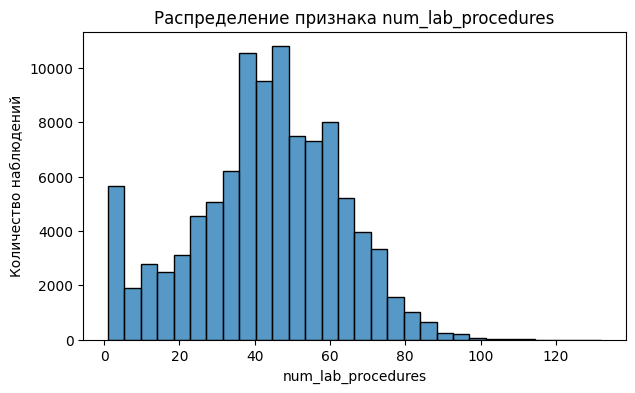

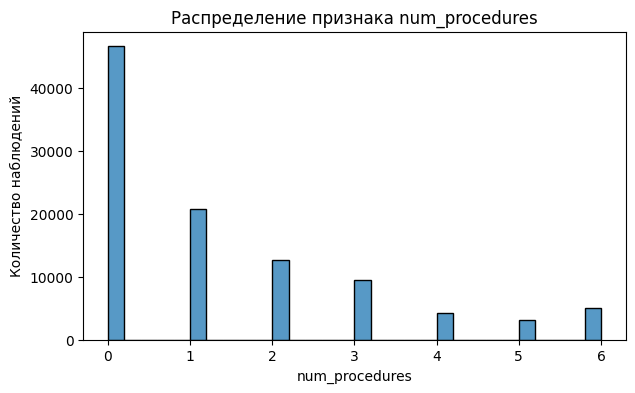

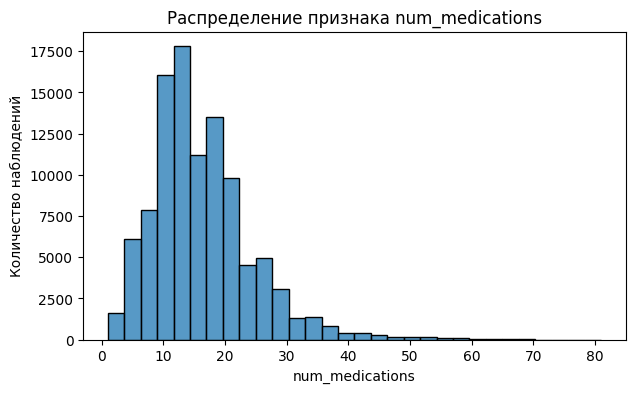

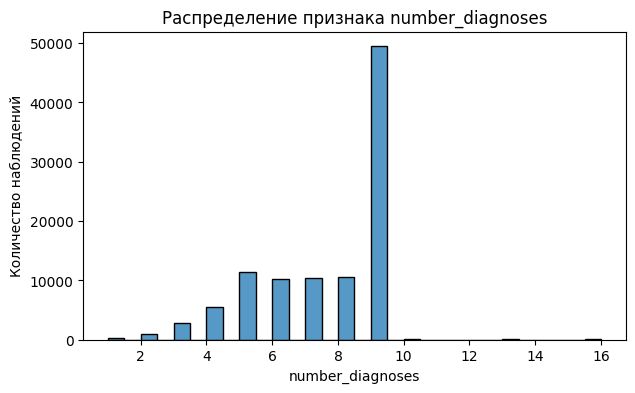

In [261]:
for col in num_current:
    plt.figure(figsize=(7, 4))

    sns.histplot(data=df, x=col, bins=30)

    plt.title(f'Распределение признака {col}')
    plt.xlabel(col)
    plt.ylabel('Количество наблюдений')

    plt.show()

По графикам видно, что большинство госпитализаций были недолгими, чаще всего пациенты находились в больнице от 1 до 4 дней.

Количество лабораторных процедур чаще всего находится в среднем диапазоне, примерно от 30 до 60. Очень большие значения встречаются редко.

Для num_procedures заметно, что чаще всего значение равно 0. Это означает, что у многих пациентов не было дополнительных процедур, кроме лабораторных.

Количество назначенных лекарств чаще всего находится примерно в диапазоне от 10 до 20, но есть пациенты с гораздо большим числом препаратов. Это может говорить о более сложном лечении.

Для number_diagnoses особенно часто встречается значение 9. Это может быть связано как с медицинской сложностью пациентов, так и с особенностями заполнения данных.

Таким образом, числовые признаки показывают разную степень сложности госпитализации. Поэтому дальше их можно сравнить с readmitted_30, чтобы понять, связана ли сложность случая с ранней повторной госпитализацией

**Признаки прошлых обращений пациента**

In [262]:
df[num_history].describe()

,number_outpatient,number_emergency,number_inpatient
count,101763.000000,101763.000000,101763.000000
mean,0.369368,0.197842,0.635585
std,1.267282,0.930485,1.262877
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,1.000000
max,42.000000,76.000000,21.000000


По таблице describe видно, что у этих признаков значения небольшие или равны 0, но есть пациенты с большим количеством прошлых обращений. Поэтому дальше я сгруппирую значения в более понятные категории: 0, 1, 2 и 3+ обращений

In [263]:
df['outpatient_group'] = pd.cut(df['number_outpatient'], bins=[-1, 0, 1, 2, 100], labels=['0', '1', '2', '3+'])

df['emergency_group'] = pd.cut(df['number_emergency'], bins=[-1, 0, 1, 2, 100], labels=['0', '1', '2', '3+'])

df['inpatient_group'] = pd.cut(df['number_inpatient'], bins=[-1, 0, 1, 2, 100], labels=['0', '1', '2', '3+'])

Такой подход делает анализ более понятным, потому что большие значения встречаются редко, и их удобнее рассматривать как отдельную общую группу

In [264]:
df['outpatient_group'].value_counts().sort_index(), df['emergency_group'].value_counts().sort_index(), df['inpatient_group'].value_counts().sort_index()

(outpatient_group
 0     85024
 1      8547
 2      3594
 3+     4598
 Name: count, dtype: int64,
 emergency_group
 0     90380
 1      7677
 2      2042
 3+     1664
 Name: count, dtype: int64,
 inpatient_group
 0     67627
 1     19521
 2      7566
 3+     7049
 Name: count, dtype: int64)

По результатам видно, что самая большая группа по каждому признаку это пациенты без прошлых обращений. Однако также есть пациенты с 1, 2 и 3+ прошлыми обращениями.

Именно эти группы интересно сравнить между собой: можно проверить, растёт ли доля ранней повторной госпитализации у пациентов с большим количеством прошлых обращений

In [265]:
outpatient_table = df.groupby('outpatient_group', observed=False)['readmitted_30'].mean() * 100
emergency_table = df.groupby('emergency_group', observed=False)['readmitted_30'].mean() * 100
inpatient_table = df.groupby('inpatient_group', observed=False)['readmitted_30'].mean() * 100

In [266]:
history = pd.DataFrame({
    'outpatient': outpatient_table,
    'emergency': emergency_table,
    'inpatient': inpatient_table})

history

,outpatient,emergency,inpatient
0,10.674633,10.474663,8.437458
1,13.923014,14.354566,12.924543
2,13.745131,18.266405,17.433254
3+,12.983906,24.939904,25.663215


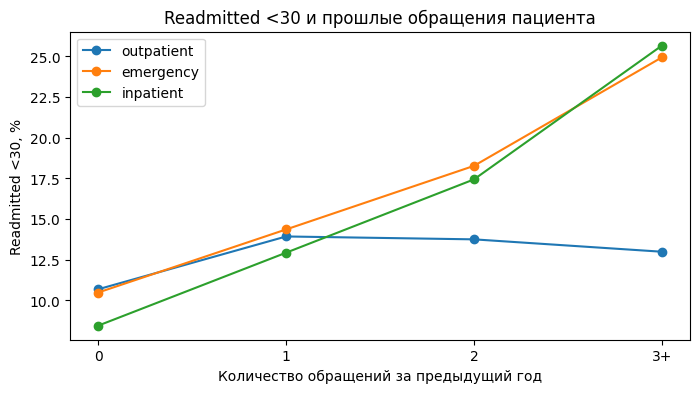

In [267]:
plt.figure(figsize=(8, 4))

plt.plot(history.index.astype(str), history['outpatient'], marker='o', label='outpatient')

plt.plot(history.index.astype(str), history['emergency'], marker='o', label='emergency')

plt.plot(history.index.astype(str), history['inpatient'], marker='o', label='inpatient')

plt.title('Readmitted <30 и прошлые обращения пациента')
plt.xlabel('Количество обращений за предыдущий год')
plt.ylabel('Readmitted <30, %')
plt.legend()

plt.show()

Линейный график показывает, как меняется доля readmitted_30 при увеличении количества прошлых обращений

Теперь сравним числовые признаки у двух групп:

readmitted_30 = 0 - не было ранней повторной госпитализации;
readmitted_30 = 1 - была ранняя повторная госпитализация.

Сможем понять отличаются ли пациенты с ранним возвращением в больницу по сложности текущей госпитализации и по истории прошлых обращений

In [268]:
num_cols = num_current + num_history

df.groupby('readmitted_30')[num_cols].mean().T

readmitted_30,0,1
time_in_hospital,4.349258,4.768249
num_lab_procedures,42.953941,44.226028
num_procedures,1.347079,1.280884
num_medications,15.911123,16.903143
number_diagnoses,7.388713,7.692789
number_outpatient,0.360883,0.436911
number_emergency,0.177809,0.357313
number_inpatient,0.561666,1.224003


По таблице средних значений можно сделать первый вывод: пациенты с readmitted_30 = 1 в среднем имеют больше прошлых inpatient- и emergency-обращений.

Также у них могут быть немного выше значения time_in_hospital, num_medications и number_diagnoses. Это говорит о том, что ранняя повторная госпитализация может быть связана как с более сложной текущей госпитализацией, так и с более тяжёлой медицинской историей пациента

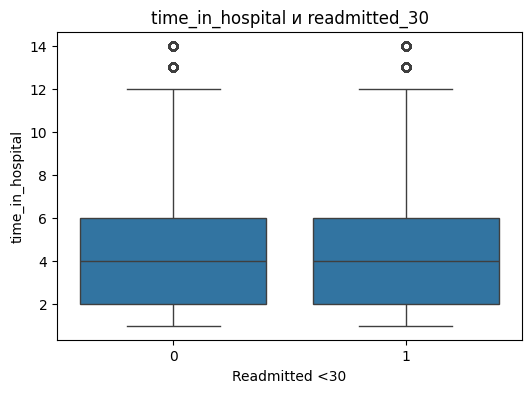

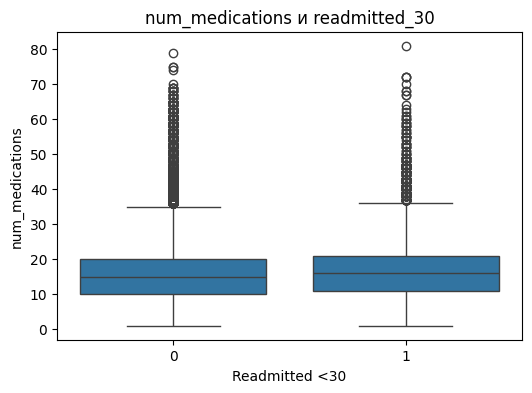

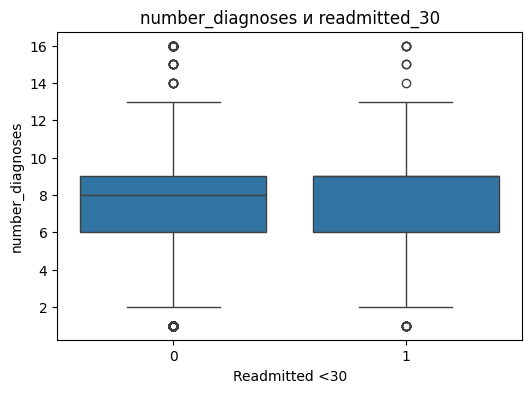

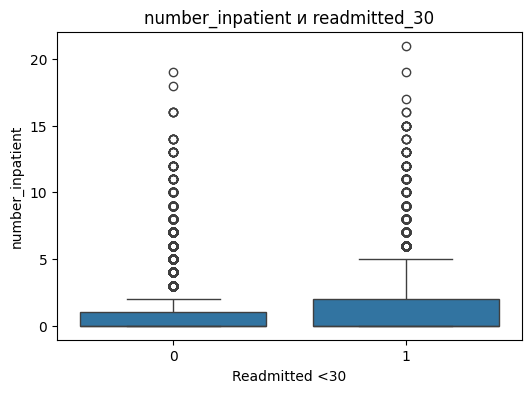

In [269]:
cols = ['time_in_hospital', 'num_medications', 'number_diagnoses', 'number_inpatient']

for col in cols:
    plt.figure(figsize=(6, 4))

    sns.boxplot(data=df, x='readmitted_30', y=col)

    plt.title(f'{col} и readmitted_30')
    plt.xlabel('Readmitted <30')
    plt.ylabel(col)

    plt.show()

Boxplot показывает распределение признаков в двух группах (с ранней повторной госпитализацией и без неё)

Для time_in_hospital и num_medications можно проверить, связаны ли более длительное пребывание в больнице и более сложная лекарственная терапия с ранним возвращением пациента.

Для number_diagnoses можно посмотреть, отличаются ли пациенты с большим количеством диагнозов.

у пациентов с readmitted_30 = 1 значения number_inpatient в целом выше, чем у пациентов с readmitted_30 = 0. Это значит, что пациенты с ранней повторной госпитализацией чаще имели госпитализации за предыдущий год

**Анализ признаков лечения диабета**

Для анализа возьму три признака:

insulin - назначался ли инсулин и менялась ли его дозировка;
change - было ли изменение диабетической терапии;
diabetesMed - назначались ли диабетические препараты.

Эти признаки важны, потому что изменение лечения или использование инсулина может быть связано с более сложным или нестабильным состоянием пациента

In [270]:
therapy_cols = ['insulin', 'change', 'diabetesMed']

In [271]:
for col in therapy_cols:
    print(df[col].value_counts())
    print()

insulin
No        47380
Steady    30849
Down      12218
Up        11316
Name: count, dtype: int64

change
No    54754
Ch    47009
Name: count, dtype: int64

diabetesMed
Yes    78361
No     23402
Name: count, dtype: int64



По распределению признаков видно, что категории внутри признаков лечения представлены неравномерно

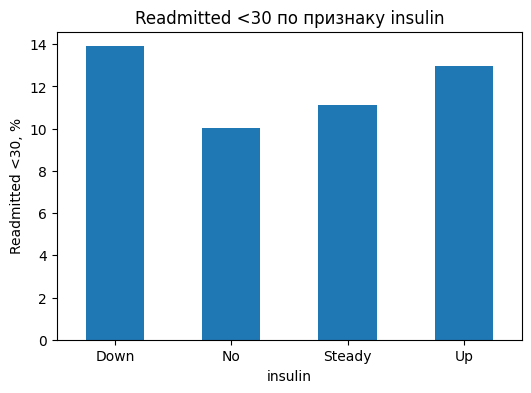

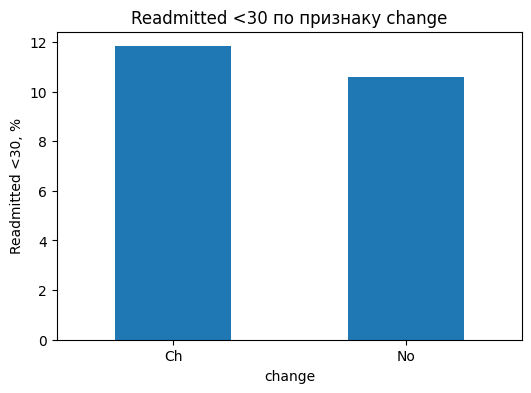

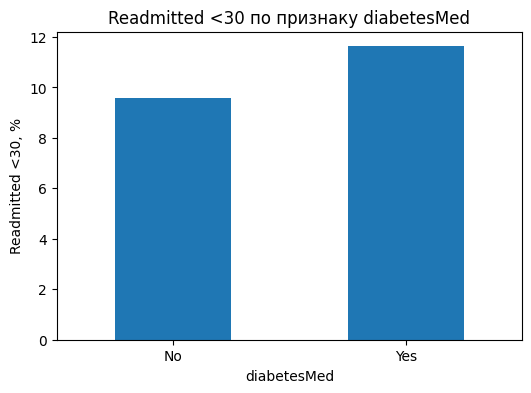

In [272]:
for col in therapy_cols:
    therapy_rate = df.groupby(col)['readmitted_30'].mean() * 100

    plt.figure(figsize=(6, 4))

    therapy_rate.plot(kind='bar')

    plt.title(f'Readmitted <30 по признаку {col}')
    plt.xlabel(col)
    plt.ylabel('Readmitted <30, %')
    plt.xticks(rotation=0)

    plt.show()

По графикам видно, что признаки лечения диабета также связаны с ранней повторной госпитализацией.

Для insulin доля readmitted_30 выше у пациентов, у которых дозировка инсулина менялась. Особенно выделяются категории Up и Down. Это может говорить о том, что изменение дозировки инсулина связано с более нестабильным состоянием пациента.

По признаку change видно, что пациенты с изменением диабетической терапии имеют более высокую долю readmitted_30, чем пациенты без изменения терапии. Это также указывает на возможную связь между сложностью лечения и ранней повторной госпитализацией.

По признаку diabetesMed различия менее выражены

**анализ распределения полов**

посмотрим на то, как распределы мужчины и женщины в выборке

In [273]:
sns.countplot(data=patient_demo, x='gender', ax=axes[0])


<Axes: title={'center': 'Распределение уникальных пациентов по полу'}, xlabel='Пол', ylabel='Количество пациентов'>

In [275]:
corr_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_diagnoses',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'readmitted_30'
]

In [276]:
corr_matrix = df[corr_cols].corr()
corr_matrix

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,number_outpatient,number_emergency,number_inpatient,readmitted_30
time_in_hospital,1.000000,0.318429,0.191497,0.466137,0.220153,-0.008919,-0.009683,0.073619,0.044197
num_lab_procedures,0.318429,1.000000,0.058105,0.268176,0.152737,-0.007606,-0.002282,0.039225,0.020359
num_procedures,0.191497,0.058105,1.000000,0.385761,0.073769,-0.024813,-0.038175,-0.066226,-0.012219
num_medications,0.466137,0.268176,0.385761,1.000000,0.261529,0.045198,0.013180,0.064196,0.038433
number_diagnoses,0.220153,0.152737,0.073769,0.261529,1.000000,0.094148,0.055536,0.104703,0.049518
number_outpatient,-0.008919,-0.007606,-0.024813,0.045198,0.094148,1.000000,0.091457,0.107334,0.018890
number_emergency,-0.009683,-0.002282,-0.038175,0.013180,0.055536,0.091457,1.000000,0.266557,0.060744
number_inpatient,0.073619,0.039225,-0.066226,0.064196,0.104703,0.107334,0.266557,1.000000,0.165143
readmitted_30,0.044197,0.020359,-0.012219,0.038433,0.049518,0.018890,0.060744,0.165143,1.000000


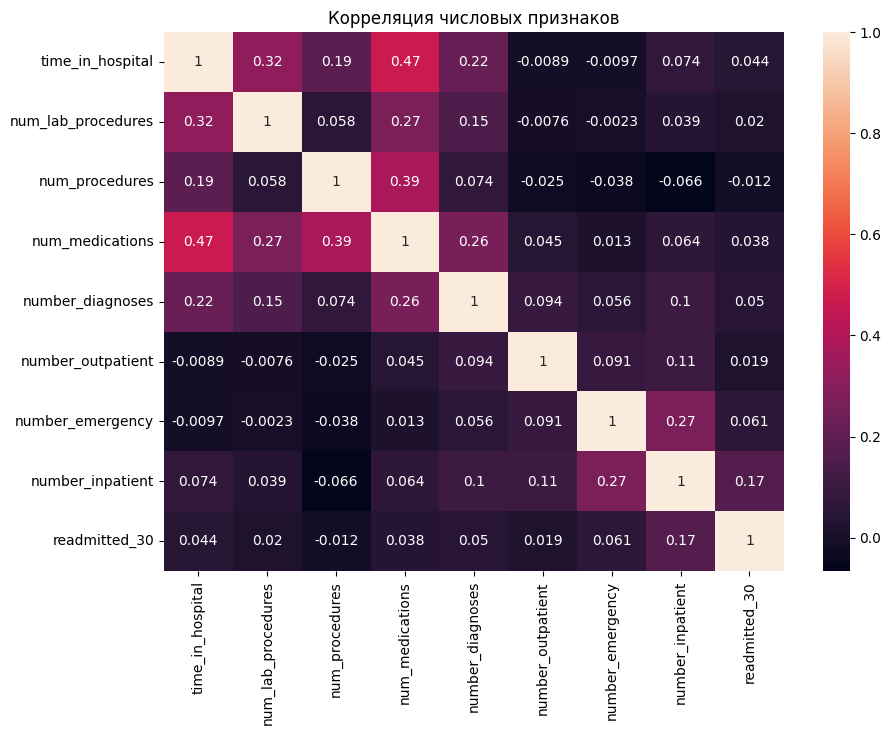

In [277]:
plt.figure(figsize=(10, 7))

sns.heatmap(corr_matrix, annot=True)

plt.title('Корреляция числовых признаков')
plt.show()

Теперь вернемся к бизнес-кейсу: как нам оценить по данным, готовы ли мы одобрить планировку.

Главный вопрос - устраивает ли нас симметричность планирвоки. Для этого нам важно отнешение мужчин и женщин в наших пациентах.

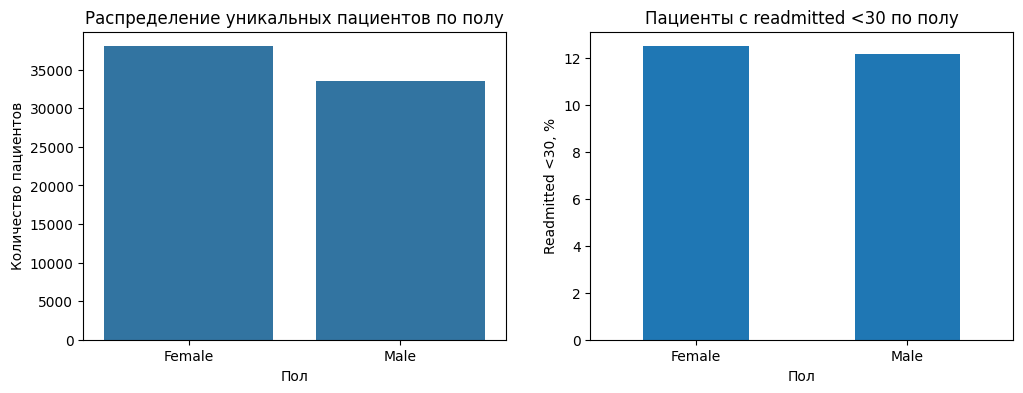

In [278]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=patient_demo, x='gender', ax=axes[0])
axes[0].set_title('Распределение уникальных пациентов по полу')
axes[0].set_xlabel('Пол')
axes[0].set_ylabel('Количество пациентов')

gender_again = patient_demo.groupby('gender')['readmitted_30'].mean() * 100

gender_again.plot(kind='bar', ax=axes[1])
axes[1].set_title('Пациенты с readmitted <30 по полу')
axes[1].set_xlabel('Пол')
axes[1].set_ylabel('Readmitted <30, %')
axes[1].tick_params(axis='x', rotation=0)

На уровне уникальных пациентов распределение по полу показывает, сколько мужчин и женщин представлено в датасете без повторного учёта одного и того же пациента.

Правый график показывает долю пациентов каждого пола, у которых хотя бы раз была ранняя повторная госпитализация

интересно, можно ли считать, что мужчин и женщин пришло одинаковое количесво:

**ГИПОТЕЗА**: Число мужчин в выборке равно числу женщин

In [290]:
from scipy.stats import chisquare
import numpy as np

n_female = np.sum(patient_demo["gender"] == "Female")
n_male =  np.sum(patient_demo["gender"] == "Male")
n_total = n_female + n_male

print(n_male, n_female, (n_female-n_male)/n_male)

stat, p = chisquare([n_female, n_male])
print(f"ch_stat={stat:.2f}, p={p:.4f}")

33490 38025 0.13541355628545834
ch_stat=287.58, p=0.0000


Видим, что у нас стат. значимо больше женщин.

Следующин интересущий нас вопрос, как зависит от пола число лабораторных процедур. Этот вопрос тоже важен для понимания нагрузки на два крыла больницы.

Также можно проверить, влияет ли на число лабораторных процедур возраст, ведь если да, стоит задуматься об особом распрложении таких комнат (для старшего поколения), чтобы отпимизировать марщруты людей.

**Гипотеза**: пол, возрастная группа и комбинация этих факторов влияют на количество медицинских процедур

Эту гипотезу проверим отдельно.

Для наглядности сделаем график.

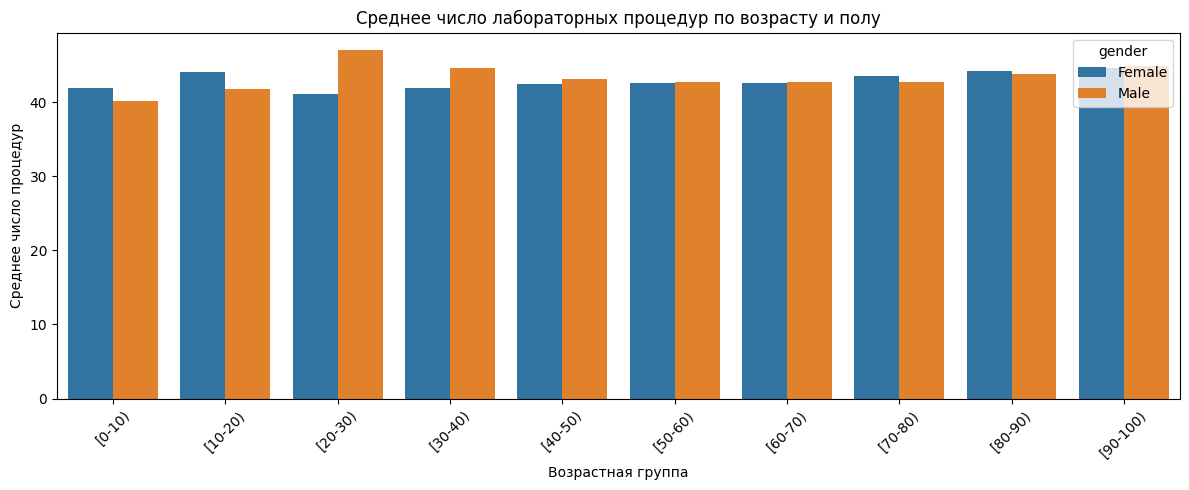

In [284]:
age_gender = df.groupby(['age', 'gender'])['num_lab_procedures']
age_gender = age_gender.mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=age_gender, x='age', y='num_lab_procedures', hue='gender')
plt.title('Среднее число лабораторных процедур по возрасту и полу')
plt.xlabel('Возрастная группа')
plt.ylabel('Среднее число процедур')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Говоря о числе процедур, нам важен еще один интресный фактор: _интенсивность_ этих процедур. То есть отношение числа лабораборных процедур к числу проведенных пациентом дней (`num_lab_procedures` / `time_in_hospital`).

Если обнаружатся серьезные различия, дисбаланс нагрузки будет еще более явный.

то есть 

**Гипотеза**: пол человека влияет на интенсивность лабораторных процедур у клиента

In [285]:
agg = df.groupby('gender')[['num_lab_procedures', 'time_in_hospital']].mean()
agg['intensity'] = agg['num_lab_procedures'] / agg['time_in_hospital']
print(agg.round(3))

        num_lab_procedures  time_in_hospital  intensity
gender                                                 
Female              43.152             4.479      9.635
Male                43.031             4.300     10.008


In [289]:
diff = agg['intensity']["Male"] - agg['intensity']["Female"]
print(f"Разница: {diff:.3f} процедур/день")

Разница: 0.373 процедур/день


Также крайне интересующий нас вопрос: можем ли мы как-то понять, какие пациенты у нас скорее всего вернутся в течение 30 дней. Посмотрим, есть ли зависимость от расы и возрастной группы на то, какая категория `readmitted` у нашего пациента

**ГИПОТЕЗА**: Категория возраста человека влияет на то, вернется ли он в стационар раньше, чем через 30 дней.

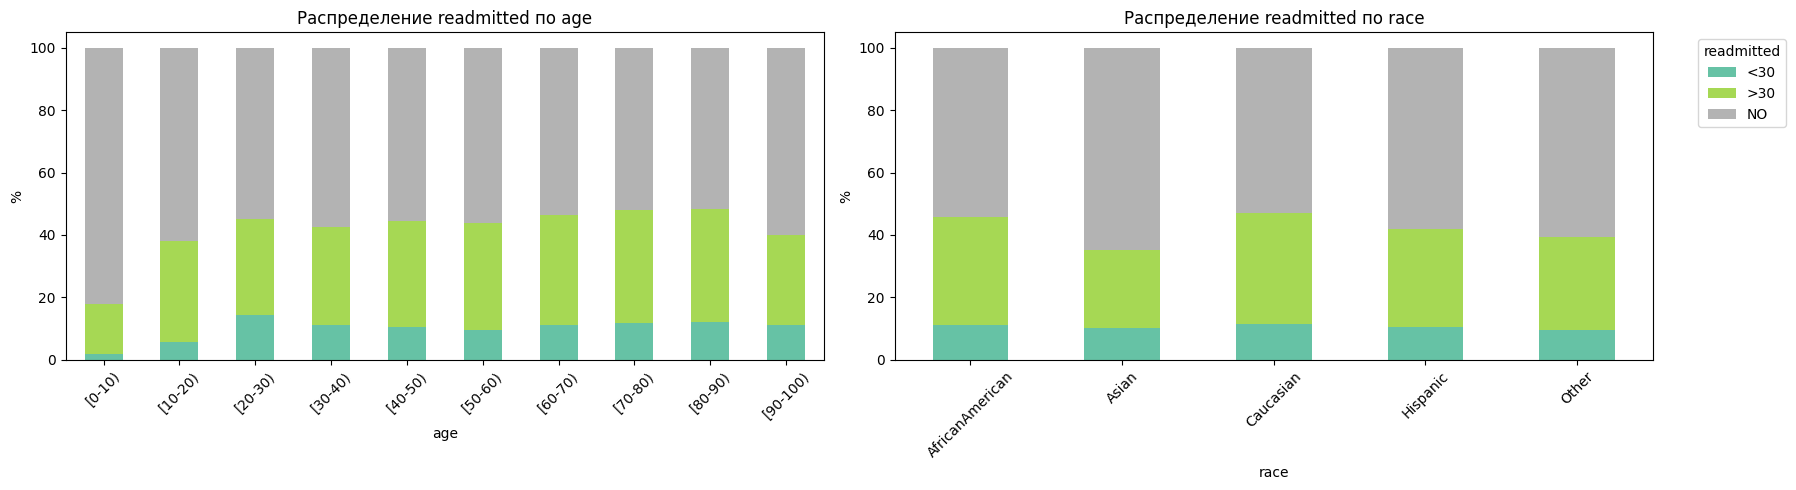

In [297]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for col, ax in zip(['age', 'race'], axes):
    ct = df.groupby([col, 'readmitted'])
    ct = ct.size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', legend=False)
    ax.set_title(f'Распределение readmitted по {col}')
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=45)

axes[1].legend(title='readmitted', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()